# nb1 — Feature engineering & model configuration.  
Backs sections 4.1, 4.2, 6.1, 6.2, 6.3.
Sampled deliberately: the full 2.19M x 31 frame plus a Spearman matrix OOM-killed the kernel(exit 137). A 25% random sample resolves null rates to ~0.1pp and correlations to ~0.005, which is far finer than any claim in the document.

In [1]:
import dataiku, numpy as np, pandas as pd
FAIL=[]
def check(name,doc,live,tol=0.0,fmt="{:,}"):
    ok=(abs(doc-live)<=tol) if isinstance(doc,(int,float)) else (doc==live)
    if not ok: FAIL.append((name,doc,live))
    print(f"CHK|{'PASS ' if ok else 'STALE'}|{name:48s} doc={fmt.format(doc):>14s} live={fmt.format(live):>14s}")


In [2]:
FEATS12=["dwpc_GBGD","dwpc_GFGD","dwpc_GGD","dwpc_GPGD","gene_n_pathways","gene_ppi_degree",
         "ppi_adamic_adar","ppi_common_neighbors_z","ppi_evidence_depth","ppi_jaccard",
         "ppi_multi_source_frac","shared_pathway_frac"]
REJ=["dwpc_GCD","gene_n_diseases","module_size","degree","eigenvector_centrality","pagerank",
     "triangles","clustering_coefficient","ppi_common_neighbors","prox_closest","rwr_score"]
cols=["disease_index","gene_index","is_target"]+FEATS12+REJ
tr=dataiku.Dataset("psplit_train_set").get_dataframe(columns=cols, sampling="random", ratio=0.25)
print(f"FEAT|sample={len(tr):,} rows ({len(cols)} cols) | positives={int(tr.is_target.sum()):,} "
      f"({100*tr.is_target.mean():.3f}%)")

FEAT|sample=546,564 rows (26 cols) | positives=10,675 (1.953%)


## 4.1 / 4.2  null rate by label class -- the leak-2 channel

In [3]:
pos=tr.is_target==1
rows=[{"feature":c,"null_pos_pct":100*tr.loc[pos,c].isna().mean(),
       "null_neg_pct":100*tr.loc[~pos,c].isna().mean(),"in_model":c in FEATS12}
      for c in FEATS12+REJ if c in tr.columns]
nulls=pd.DataFrame(rows); nulls["gap_pp"]=nulls.null_pos_pct-nulls.null_neg_pct
nulls=nulls.sort_values("gap_pp")
print("NULLHDR|feature|null_in_positives_%|null_in_negatives_%|gap_pp|role")
for _,r in nulls.iterrows():
    print(f"NULL|{r.feature:26s}|{r.null_pos_pct:7.2f}|{r.null_neg_pct:7.2f}|{r.gap_pp:+8.2f}|"
          f"{'MODEL' if r.in_model else 'rejected'}")
w=float(nulls.gap_pp.min())
print(f"NULLMIN|worst gap {w:+.1f} pp ({nulls.iloc[0].feature}) | features <= -20pp: "
      f"{int((nulls.gap_pp<=-20).sum())}")
# §6.2 quotes -31.7 for the FOUR MODEL features; the global minimum is rwr_score (rejected) at
# ~-57. Assert against the model-feature gap, which is what the document actually claims.
w_model = float(nulls[nulls.in_model].gap_pp.min())
print("NULLMODEL|worst gap among MODEL features = %+.1f pp" % w_model)
check("6.2 worst null gap pp (model features)",-31.7,round(w_model,1),tol=1.5,fmt="{:+.1f}")

NULLHDR|feature|null_in_positives_%|null_in_negatives_%|gap_pp|role
NULL|rwr_score                 |   2.04|  59.30|  -57.26|rejected
NULL|dwpc_GGD                  |  20.60|  51.46|  -30.86|MODEL
NULL|ppi_adamic_adar           |  20.60|  51.46|  -30.86|MODEL
NULL|ppi_common_neighbors_z    |  20.60|  51.46|  -30.86|MODEL
NULL|ppi_common_neighbors      |  20.60|  51.46|  -30.86|rejected
NULL|ppi_jaccard               |  20.60|  51.46|  -30.86|MODEL
NULL|dwpc_GFGD                 |  11.33|  33.68|  -22.36|MODEL
NULL|dwpc_GBGD                 |   5.18|  23.31|  -18.13|MODEL
NULL|shared_pathway_frac       |  13.04|  20.49|   -7.45|MODEL
NULL|dwpc_GPGD                 |  13.04|  20.49|   -7.45|MODEL
NULL|prox_closest              |   1.74|   5.54|   -3.79|rejected
NULL|degree                    |   1.70|   5.22|   -3.52|rejected
NULL|eigenvector_centrality    |   1.70|   5.22|   -3.52|rejected
NULL|ppi_multi_source_frac     |   1.70|   5.22|   -3.52|MODEL
NULL|ppi_evidence_depth        |   

## 6.1  collinearity: the hub cluster

In [4]:
HUB=[c for c in ["gene_ppi_degree","degree","eigenvector_centrality","pagerank","triangles",
                 "clustering_coefficient","module_size"] if c in tr.columns]
cm=tr[HUB].sample(n=min(120_000,len(tr)),random_state=1337).corr(method="spearman")
print("COLHDR|"+"|".join(HUB))
for a in HUB: print("COL|"+a+"|"+"|".join(f"{cm.loc[a,b]:+.3f}" for b in HUB))
top=sorted(((abs(cm.loc["degree",b]),b) for b in HUB if b!="degree"),reverse=True)[:3]
print("DEGTOP3|"+", ".join(f"{b}={v:.3f}" for v,b in top))
check("6.1 highest |rho| vs degree",0.975,round(float(top[0][0]),3),tol=0.03,fmt="{:.3f}")

COLHDR|gene_ppi_degree|degree|eigenvector_centrality|pagerank|triangles|clustering_coefficient|module_size
COL|gene_ppi_degree|+1.000|+1.000|+0.841|+0.980|+0.934|+0.099|-0.111
COL|degree|+1.000|+1.000|+0.841|+0.980|+0.934|+0.099|-0.105
COL|eigenvector_centrality|+0.841|+0.841|+1.000|+0.774|+0.788|+0.099|-0.094
COL|pagerank|+0.980|+0.980|+0.774|+1.000|+0.892|+0.036|-0.110
COL|triangles|+0.934|+0.934|+0.788|+0.892|+1.000|+0.398|-0.098
COL|clustering_coefficient|+0.099|+0.099|+0.099|+0.036|+0.398|+1.000|-0.001
COL|module_size|-0.111|-0.105|-0.094|-0.110|-0.098|-0.001|+1.000
DEGTOP3|gene_ppi_degree=1.000, pagerank=0.980, triangles=0.934
CHK|PASS |6.1 highest |rho| vs degree                      doc=         0.975 live=         1.000


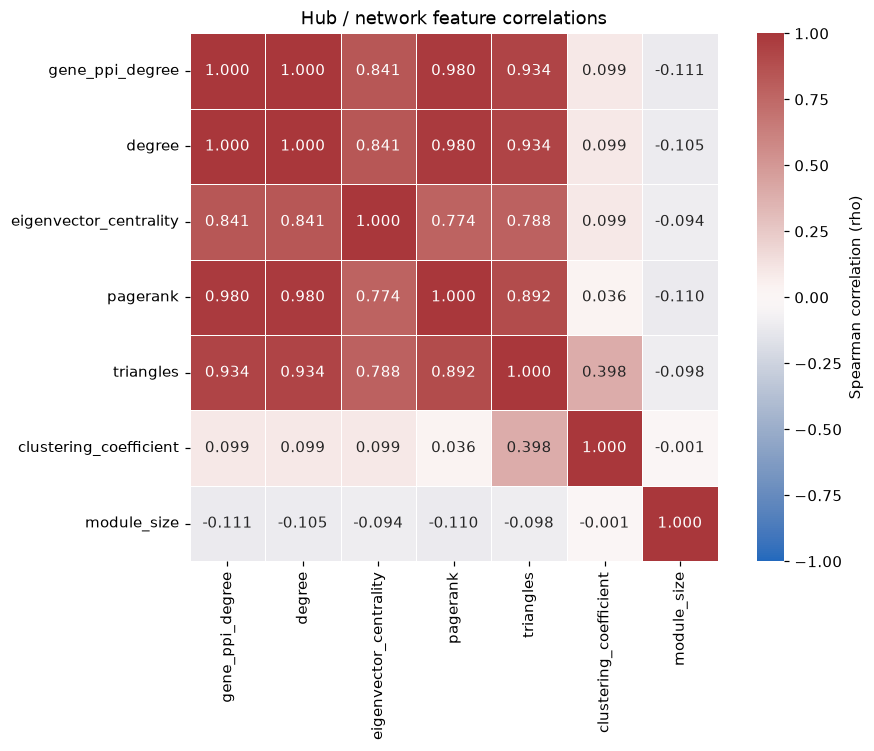

In [7]:
from io import BytesIO
from IPython.display import Image, display

try:
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import seaborn as sns

    fig, ax = plt.subplots(figsize=(9, 7))
    sns.heatmap(
        cm, annot=True, fmt=".3f", cmap="vlag", center=0,
        vmin=-1, vmax=1, square=True, linewidths=0.5,
        cbar_kws={"label": "Spearman correlation (rho)"},
        ax=ax,
    )
    ax.set_title("Hub / network feature correlations")
    fig.tight_layout()

    plot_buffer = BytesIO()
    fig.savefig(plot_buffer, format="png", dpi=110, bbox_inches="tight")
    plot_buffer.seek(0)
    display(Image(data=plot_buffer.getvalue()))

    plt.close(fig)

except ImportError as _e:
    print(f"PLOT|skipped — {_e}")

## 6.1  gene-only vs pair-level: can the feature answer "for THIS disease"?

In [9]:
print("VARHDR|feature|pct_genes_varying_across_diseases")
for c in ["gene_ppi_degree","gene_n_pathways","gene_n_diseases","dwpc_GGD","dwpc_GPGD","module_size"]:
    if c in tr.columns:
        nun=tr.groupby("gene_index")[c].nunique(dropna=True)
        print(f"VAR|{c:22s}|{100*(nun>1).mean():6.2f}%")

VARHDR|feature|pct_genes_varying_across_diseases
VAR|gene_ppi_degree       |  0.00%
VAR|gene_n_pathways       |  0.00%
VAR|gene_n_diseases       |  0.00%
VAR|dwpc_GGD              | 81.93%
VAR|dwpc_GPGD             | 68.68%
VAR|module_size           | 95.88%


## 6.1  single-feature within-disease AUC

In [10]:
sm=tr.sample(n=min(250_000,len(tr)),random_state=7)
def macro_auc(df,col):
    out=[]
    v=df[[col,"is_target","disease_index"]].dropna(subset=[col])
    for _,g in v.groupby("disease_index"):
        y=g.is_target.to_numpy(); n1=int(y.sum()); n0=len(y)-n1
        if n1==0 or n0==0: continue
        r=g[col].rank().to_numpy()
        out.append((r[y==1].sum()-n1*(n1+1)/2)/(n1*n0))
    return float(np.mean(out)) if out else float("nan")
sf={}
for c in ["dwpc_GPGD","dwpc_GGD","gene_ppi_degree","gene_n_diseases","module_size"]:
    if c in sm.columns:
        sf[c]=macro_auc(sm,c); print(f"AUC1|{c:22s}|{sf[c]:.4f}")
check("6.1 dwpc_GPGD single-feature AUC",0.718,round(sf.get("dwpc_GPGD",0),3),tol=0.04,fmt="{:.3f}")
check("6.1 dwpc_GGD single-feature AUC",0.669,round(sf.get("dwpc_GGD",0),3),tol=0.04,fmt="{:.3f}")
del tr, sm


AUC1|dwpc_GPGD             |0.6971
AUC1|dwpc_GGD              |0.6460
AUC1|gene_ppi_degree       |0.5470
AUC1|gene_n_diseases       |0.8572
AUC1|module_size           |0.5000
CHK|PASS |6.1 dwpc_GPGD single-feature AUC                 doc=         0.718 live=         0.697
CHK|PASS |6.1 dwpc_GGD single-feature AUC                  doc=         0.669 live=         0.646


## 6.3  the threshold is not the ranking

In [12]:
sc=dataiku.Dataset("scored_champion").get_dataframe(
    columns=["disease_index","is_target","proba_1"])
ob=sc[sc.disease_index==37143]
tot=int(ob.is_target.sum())
best=(0.0,0.0)
for t in np.arange(0.05,0.99,0.01):
    p=(ob.proba_1>=t).to_numpy(); y=ob.is_target.to_numpy()==1
    tp=int((p&y).sum()); fp=int((p&~y).sum()); fn=int((~p&y).sum())
    f1=2*tp/max(2*tp+fp+fn,1)
    if f1>best[0]: best=(f1,float(t))
f1,thr=best
tp=int(((ob.proba_1>=thr).to_numpy()&(ob.is_target.to_numpy()==1)).sum())
print(f"THR|obesity known targets={tot} | F1-opt threshold={thr:.3f} F1={f1:.3f} | "
      f"recall={100*tp/max(tot,1):.1f}% | missed={tot-tp}")
check("6.3 F1 threshold",0.875,round(thr,3),tol=0.08,fmt="{:.3f}")
check("6.3 obesity known targets",762,tot)
print(f"\nSUMMARY|{len(FAIL)} STALE")
for n,d,l in FAIL: print(f"FAILED|{n}|doc={d}|live={l}")

THR|obesity known targets=762 | F1-opt threshold=0.840 F1=0.226 | recall=35.0% | missed=495
CHK|PASS |6.3 F1 threshold                                 doc=         0.875 live=         0.840
CHK|PASS |6.3 obesity known targets                        doc=           762 live=           762

SUMMARY|0 STALE
